In [1]:
from google.colab import files
files.upload()  # upload the zip

import zipfile

with zipfile.ZipFile("medical_sample_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

Saving medical_sample_dataset.zip to medical_sample_dataset.zip


Found 32 images belonging to 2 classes.
Found 8 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 412ms/step - accuracy: 0.4688 - loss: 0.8309 - val_accuracy: 0.5000 - val_loss: 0.7034
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 0.5000 - loss: 0.7115 - val_accuracy: 0.5000 - val_loss: 0.6948
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 321ms/step - accuracy: 0.5312 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 330ms/step - accuracy: 0.4688 - loss: 0.6923 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step - accuracy: 0.5938 - loss: 0.6911 - val_accuracy: 0.5000 - val_loss: 0.6948


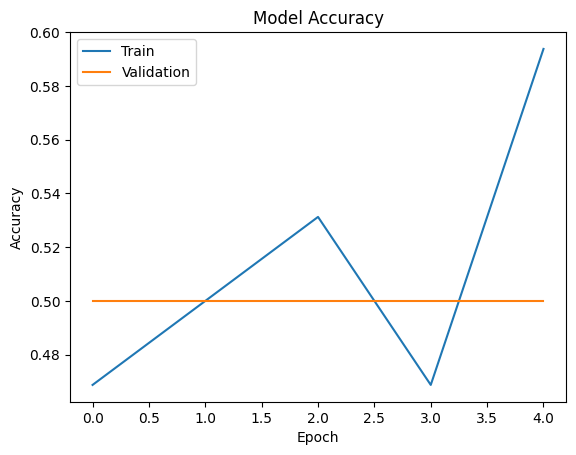

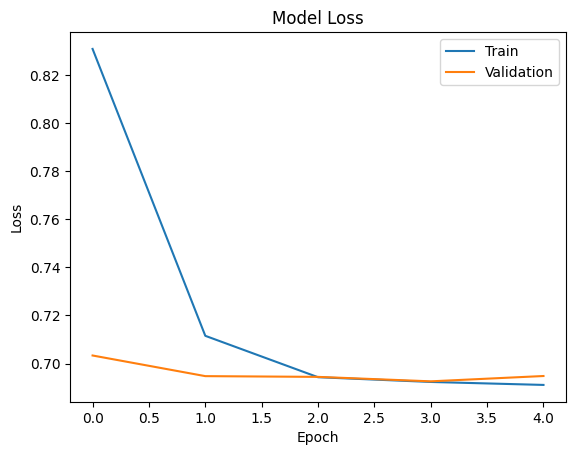

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


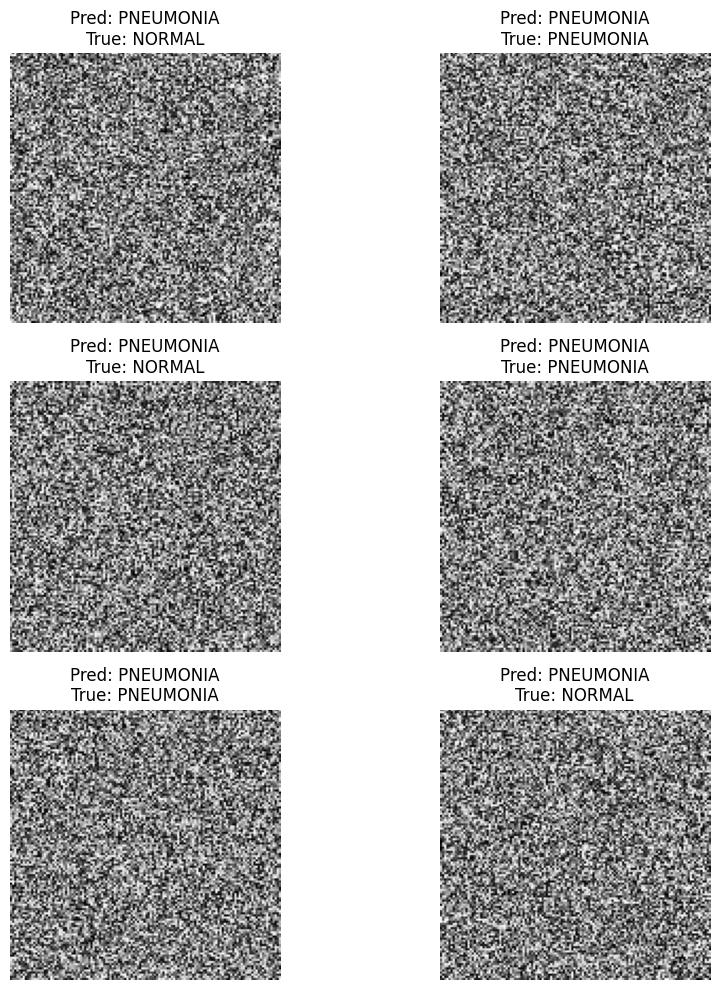

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.5000 - loss: 0.6948
Final Accuracy: 0.5


In [2]:
# =========================
#  IMPORTS
# =========================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

# =========================
#  DATA PATH
# =========================
data_dir = "data"

# =========================
#  DATA PREPROCESSING
# =========================
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=8,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=8,
    class_mode='binary',
    subset='validation'
)

# =========================
#  CNN MODEL
# =========================
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# =========================
#  COMPILE
# =========================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
#  TRAIN MODEL
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

# =========================
#  ACCURACY GRAPH
# =========================
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# =========================
#  LOSS GRAPH
# =========================
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

# =========================
#  PREDICTIONS VISUALIZATION
# =========================
class_names = list(train_data.class_indices.keys())

images, labels = next(val_data)

preds = model.predict(images)

plt.figure(figsize=(10,10))

for i in range(6):
    plt.subplot(3,2,i+1)
    plt.imshow(images[i])
    plt.axis('off')

    pred_label = "PNEUMONIA" if preds[i] > 0.5 else "NORMAL"
    true_label = class_names[int(labels[i])]

    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")

plt.tight_layout()
plt.show()

# =========================
#  FINAL EVALUATION
# =========================
loss, acc = model.evaluate(val_data)
print("Final Accuracy:", acc)